# K-Nearest Neighbors - KNN

Utilizado tanto para tarefas de classificação quanto de regressão, sua simplicidade e eficácia o tornam um ponto de partida popular para muitos problemas em ciência de dados.

A lógica central do KNN se baseia em um conceito simples: **``"diga-me com quem andas e te direi quem és".``**
- Essencialmente, um novo dado é classificado com base na classe da maioria de seus vizinhos mais próximos.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [8]:
# Carrega os dados do CSV. Delimiter="," idica que as colunas são separadas por virgulas.
# skiprows=2 para pular as duas linhas de cabeçalho/cometario.
dataset = np.loadtxt("tumores.csv", delimiter=',', skiprows=2)

# Separa as colunas de caracteristicas (features) e a coluna de rotulos (lavels)
# X_train recebe todas as linhas, mas apenas as duas primeiras colunas (indice 0 e 1)
X_train = dataset[:, :2]

#y_trains recebe todas as linhas, mas apenas a ultima coluna (indice 2)
# .astpe(int) para garantir que as classes sejam tratadas como inteiros
y_train = dataset[:, 2].astype(int)

print('Amostra das caracteristicas (X_train):')
print(X_train[:5])
print('\nAmostra dos rótulos (y_train):')
print(y_train[:5])


Amostra das caracteristicas (X_train):
[[1.9 2.5]
 [3.  3.9]
 [3.5 2.9]
 [2.2 2.2]
 [4.  4.5]]

Amostra dos rótulos (y_train):
[0 0 0 0 0]


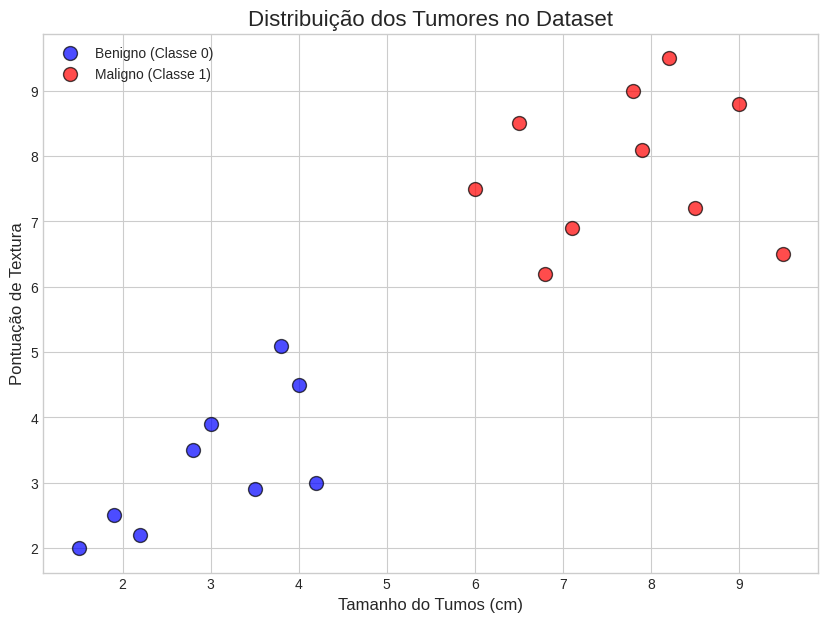

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 7))

# Plota os pontos Benignos (Classe 0)
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 
           c = 'blue', s=100, edgecolor='k', alpha=0.7, label='Benigno (Classe 0)')

# Plota os pontos Malignos (Classe 1)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 
           c = 'red', s=100, edgecolor='k', alpha=0.7, label='Maligno (Classe 1)')

ax.set_title('Distribuição dos Tumores no Dataset', fontsize=16)
ax.set_xlabel('Tamanho do Tumos (cm)', fontsize=12)
ax.set_ylabel('Pontuação de Textura', fontsize=12)
ax.legend()
plt.show()

In [10]:
def calcular_distancia_euclidiana(ponto1 , ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos mais próximos de um ponto de teste."""
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

    # Ordena a lista de distancias em ordem crescente
    distancias.sort(key=lambda x: x[0])

    # Retorna os k vizinhos mais proximos (seus rótulos)
    vizinhos = [ distancia[1] for distancia in distancias[:k]]
    return vizinhos

def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto majoritário dos vizinhos."""
    # Conta a ocorrência de cada classe nos vizinhos
    contagem_votos = Counter(vizinhos)
    # Retorna a classe mais comum
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

In [11]:
# Ponto que queremos classificar 
novo_tumor = np.array([5.5,6.0])
k = 5

# Encontra os vizinhos e faz a previsão
vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_tumor, k)
previsao_final = prever_classificacao(vizinhos_proximos)

# Mapaia o resultado para um texto explicativo
resultado_texto = "Benigno" if previsao_final == 0 else "Maligno"

print(f"O novo tumor tem as caracteristicas: {novo_tumor}")
print(f"O valor de 'k' escolhido foi: {k}")
print(f"As classes dos vizinhos mais proximos são: {vizinhos_proximos}")
print("----------------------------------------------------------")
print(f"--> Previsão final: O novo tumor é classificado como {resultado_texto} (Classe {previsao_final})")

O novo tumor tem as caracteristicas: [5.5 6. ]
O valor de 'k' escolhido foi: 5
As classes dos vizinhos mais proximos são: [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
----------------------------------------------------------
--> Previsão final: O novo tumor é classificado como Maligno (Classe 1)


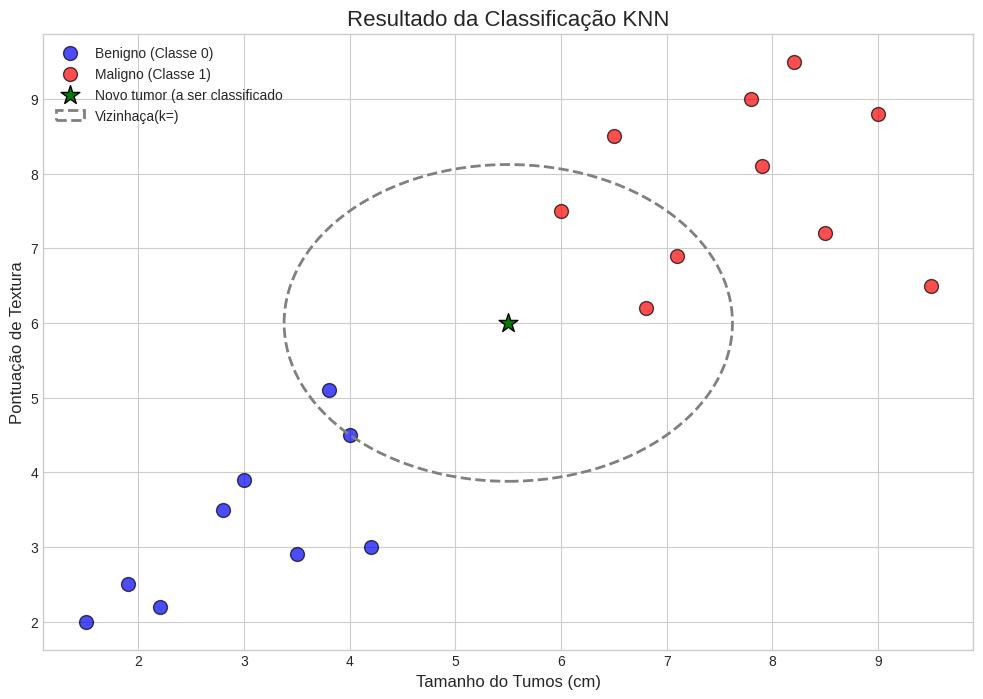

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plotando os pontos de dados de treinamento
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='blue', s=100, edgecolor='k', alpha=0.7, label='Benigno (Classe 0)')

ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='red', s=100, edgecolor='k', alpha=0.7, label='Maligno (Classe 1)')

# Plotando o novo ponto de dados a ser classificado
ax.scatter(novo_tumor[0], novo_tumor[1], c='green', s=200, edgecolor='k', marker='*', label='Novo tumor (a ser classificado')

# Destaque para os vizinho mais proximo
indices_vizinhos = np.argsort([calcular_distancia_euclidiana(p, novo_tumor) for p in X_train])[:k]
pontos_vizinhos = X_train[indices_vizinhos]

# Desenhando um circulo que engloba os vizinhos
distancia_maxima = calcular_distancia_euclidiana(novo_tumor, pontos_vizinhos[-1])
circulo = plt.Circle(novo_tumor, distancia_maxima, color='gray', fill=False, linestyle='--', linewidth=2, label=f'Vizinhaça(k=)')
ax.add_artist(circulo)

# Configurações do grafico
ax.set_title('Resultado da Classificação KNN', fontsize=16)
ax.set_xlabel('Tamanho do Tumos (cm)', fontsize=12)
ax.set_ylabel('Pontuação de Textura', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True)
plt.show()